In [1]:
# Data manipulation and preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
# Evaluation metrics
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score, make_scorer, roc_curve, accuracy_score)

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2, RFE

# Data balancing (if necessary)
from imblearn.over_sampling import SMOTE

# Handling warnings
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# Load the dataset

df = pd.read_csv("df_filtered.csv")

# Filter the dataset to keep only "Parkinson's" and "Other_Disorders", discarding "Healthy"
df_filtered = df[df['Rencoded'].isin(["Parkinson's", 'Other_Disorders'])]

In [3]:
df_filtered_info = df_filtered.info()
df_filtered_head = df_filtered.head()

df_filtered_info, df_filtered_head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   resource_type_x              390 non-null    object
 1   id_x                         390 non-null    int64 
 2   study_id_x                   390 non-null    object
 3   condition                    390 non-null    object
 4   disease_comment              390 non-null    object
 5   age_at_diagnosis             390 non-null    int64 
 6   age                          390 non-null    int64 
 7   height                       390 non-null    int64 
 8   weight                       390 non-null    int64 
 9   gender                       390 non-null    object
 10  handedness                   390 non-null    object
 11  appearance_in_kinship        390 non-null    int64 
 12  effect_of_alcohol_on_tremor  390 non-null    object
 13  resource_type_y              390 no

(None,
   resource_type_x  id_x study_id_x                 condition  \
 0         patient     2       PADS  Other Movement Disorders   
 1         patient     4       PADS               Parkinson's   
 2         patient     5       PADS               Parkinson's   
 3         patient     6       PADS               Parkinson's   
 4         patient     7       PADS  Other Movement Disorders   
 
                                      disease_comment  age_at_diagnosis  age  \
 0  Left-Sided resting tremor and hypokinesia with...                69   81   
 1                            IPS akinetic-rigid type                63   67   
 2                            IPS tremordominant type                65   75   
 3  IPS currently inpatient treatment for epilepsy...                60   72   
 4                                       Atypical IPS                73   74   
 
    height  weight  gender  ... Daytime sleepiness  Insomnia  \
 0     193     104    male  ...                  1     

In [4]:
df_filtered.shape

(390, 55)

In [5]:
print(df_filtered.isnull().sum())

resource_type_x                0
id_x                           0
study_id_x                     0
condition                      0
disease_comment                0
age_at_diagnosis               0
age                            0
height                         0
weight                         0
gender                         0
handedness                     0
appearance_in_kinship          0
effect_of_alcohol_on_tremor    0
resource_type_y                0
subject_id                     0
study_id_y                     0
id_y                           0
questionnaire_name             0
item                           0
Symptoms                       0
Dribbling                      0
Swallowing                     0
Vomiting                       0
Constipation                   0
Bowel inconsistence            0
Bowel emptying incomplete      0
Urgency                        0
Nocturia                       0
Pains                          0
Weight                         0
Sweating  

In [6]:
df_filtered = df_filtered.drop('appearance_in_kinship', axis=1) #dropping this column as it's not that important
df_filtered = df_filtered.drop('resource_type_x', axis=1) #dropping this column as it's not that important
df_filtered = df_filtered.drop('condition_Healthy', axis=1) #dropping this column healthy not required

In [7]:
print(df_filtered.isnull().sum())

id_x                           0
study_id_x                     0
condition                      0
disease_comment                0
age_at_diagnosis               0
age                            0
height                         0
weight                         0
gender                         0
handedness                     0
effect_of_alcohol_on_tremor    0
resource_type_y                0
subject_id                     0
study_id_y                     0
id_y                           0
questionnaire_name             0
item                           0
Symptoms                       0
Dribbling                      0
Swallowing                     0
Vomiting                       0
Constipation                   0
Bowel inconsistence            0
Bowel emptying incomplete      0
Urgency                        0
Nocturia                       0
Pains                          0
Weight                         0
Sweating                       0
Diplopia                       0
Rememberin

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

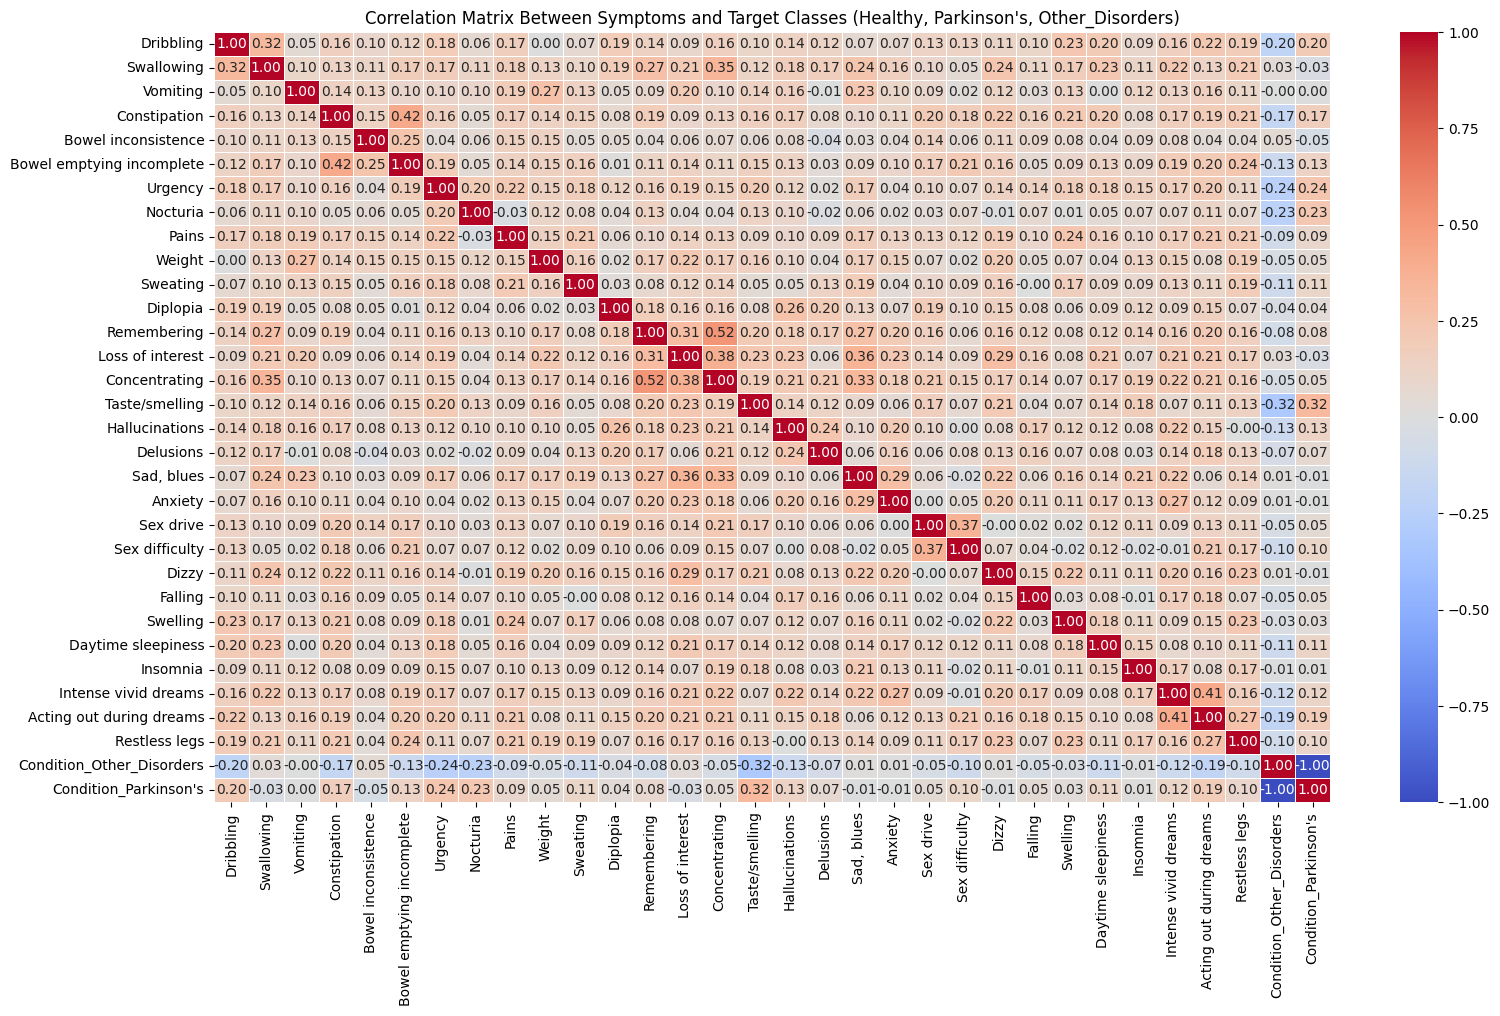

In [9]:
# Select relevant symptom columns
symptom_columns = ['Dribbling', 'Swallowing', 'Vomiting', 'Constipation', 'Bowel inconsistence',
                   'Bowel emptying incomplete', 'Urgency', 'Nocturia', 'Pains', 'Weight',
                   'Sweating', 'Diplopia', 'Remembering', 'Loss of interest', 'Concentrating',
                   'Taste/smelling', 'Hallucinations', 'Delusions', 'Sad, blues', 'Anxiety',
                   'Sex drive', 'Sex difficulty', 'Dizzy', 'Falling', 'Swelling',
                   'Daytime sleepiness', 'Insomnia', 'Intense vivid dreams',
                   'Acting out during dreams', 'Restless legs']

# One-hot encode the target column (Rencoded)
target_one_hot = pd.get_dummies(df['Rencoded'], prefix='Condition')

# Combine symptom columns with the one-hot encoded target columns
symptom_df = pd.concat([df[symptom_columns], target_one_hot], axis=1)

# Compute the correlation matrix
corr_matrix = symptom_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Between Symptoms and Target Classes (Healthy, Parkinson\'s, Other_Disorders)')
plt.show()

In [10]:
# Features and target
X = df_filtered[symptom_columns]
y = df_filtered['Rencoded'].apply(lambda x: 1 if x == "Parkinson's" else 0)

10-Classification

In [ ]:
# Split the dataset (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define classification models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGB": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100),
    "LightGBM": lgb.LGBMClassifier()
}

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Iterate over each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    fold_results = []  # To collect results for each fold

    # Cross-validated predictions
    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_train_scaled, y_train)):
        X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(X_fold_train, y_fold_train)
        y_fold_pred = model.predict(X_fold_val)

        # Store the classification report for this fold
        report = classification_report(y_fold_val, y_fold_pred, output_dict=True, zero_division=0)
        fold_results.append(report)

        # Print classification report for this fold
        print(f"\nClassification Report for Fold {fold_idx + 1}:")
        print(classification_report(y_fold_val, y_fold_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted averages for cross-validation results
    weighted_avg_precision = np.mean([result['weighted avg']['precision'] for result in fold_results])
    weighted_avg_recall = np.mean([result['weighted avg']['recall'] for result in fold_results])
    weighted_avg_f1 = np.mean([result['weighted avg']['f1-score'] for result in fold_results])

    print(f"\nWeighted Average (Training) for {name}:")
    print(f"Precision: {weighted_avg_precision:.2f}, Recall: {weighted_avg_recall:.2f}, F1-Score: {weighted_avg_f1:.2f}")

    # Fit the model on the entire training set for testing
    model.fit(X_train_scaled, y_train)

    # Get predictions for testing set
    y_test_pred = model.predict(X_test_scaled)

    # Compute accuracy for testing predictions
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print(f"\nAccuracy for {name} (Testing): {accuracy_test:.2f}")

    # Print the classification report for testing predictions
    print(f"\nClassification Report for {name} (Testing):")
    test_report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    print(classification_report(y_test, y_test_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted average for testing results
    weighted_test_precision = test_report['weighted avg']['precision']
    weighted_test_recall = test_report['weighted avg']['recall']
    weighted_test_f1 = test_report['weighted avg']['f1-score']

    # Display confusion matrix for the test set
    print(f"\nConfusion Matrix for {name} (Testing):")
    print(confusion_matrix(y_test, y_test_pred))

    print(f"\nWeighted Average (Testing) for {name}:")
    print(f"Precision: {weighted_test_precision:.2f}, Recall: {weighted_test_recall:.2f}, F1-Score: {weighted_test_f1:.2f}")



Training KNN...

Classification Report for Fold 1:
                precision    recall  f1-score   support

No Parkinson's       0.36      0.44      0.40         9
   Parkinson's       0.76      0.70      0.73        23

      accuracy                           0.62        32
     macro avg       0.56      0.57      0.56        32
  weighted avg       0.65      0.62      0.64        32


Classification Report for Fold 2:
                precision    recall  f1-score   support

No Parkinson's       0.56      0.50      0.53        10
   Parkinson's       0.78      0.82      0.80        22

      accuracy                           0.72        32
     macro avg       0.67      0.66      0.66        32
  weighted avg       0.71      0.72      0.71        32


Classification Report for Fold 3:
                precision    recall  f1-score   support

No Parkinson's       0.50      0.44      0.47         9
   Parkinson's       0.78      0.82      0.80        22

      accuracy                

In [12]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.1 MB/s eta 0:00:00


In [15]:
# Split the dataset (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Import necessary libraries
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    # Polynomial Regression with degree 2
    "Polynomial Regression (Degree 2)": Pipeline([
        ("poly_features", PolynomialFeatures(degree=2)),
        ("linear_regression", LinearRegression())
    ]),

    # SVM with RBF kernel
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1, gamma='scale', probability=True),

    # Multi-Layer Perceptron (MLP)
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),

    # CatBoost Classifier
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
}

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Iterate over each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    fold_results = []  # To collect results for each fold

    # Cross-validated predictions
    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_train_scaled, y_train)):
        X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        if "Polynomial Regression" in name:
            # Polynomial Regression expects continuous target values
            model.fit(X_fold_train, y_fold_train)
            y_fold_pred = model.predict(X_fold_val)
            y_fold_pred = np.where(y_fold_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
        else:
            model.fit(X_fold_train, y_fold_train)
            y_fold_pred = model.predict(X_fold_val)

        # Store the classification report for this fold
        report = classification_report(y_fold_val, y_fold_pred, output_dict=True, zero_division=0)
        fold_results.append(report)

        # Print classification report for this fold
        print(f"\nClassification Report for Fold {fold_idx + 1}:")
        print(classification_report(y_fold_val, y_fold_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted averages for cross-validation results
    weighted_avg_precision = np.mean([result['weighted avg']['precision'] for result in fold_results])
    weighted_avg_recall = np.mean([result['weighted avg']['recall'] for result in fold_results])
    weighted_avg_f1 = np.mean([result['weighted avg']['f1-score'] for result in fold_results])

    print(f"\nWeighted Average (Training) for {name}:")
    print(f"Precision: {weighted_avg_precision:.2f}, Recall: {weighted_avg_recall:.2f}, F1-Score: {weighted_avg_f1:.2f}")

    # Fit the model on the entire training set for testing
    if "Polynomial Regression" in name:
        model.fit(X_train_scaled, y_train)
        y_test_pred = model.predict(X_test_scaled)
        y_test_pred = np.where(y_test_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
    else:
        model.fit(X_train_scaled, y_train)
        y_test_pred = model.predict(X_test_scaled)

    # Compute accuracy for testing predictions
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print(f"\nAccuracy for {name} (Testing): {accuracy_test:.2f}")

    # Print the classification report for testing predictions
    print(f"\nClassification Report for {name} (Testing):")
    test_report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    print(classification_report(y_test, y_test_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted average for testing results
    weighted_test_precision = test_report['weighted avg']['precision']
    weighted_test_recall = test_report['weighted avg']['recall']
    weighted_test_f1 = test_report['weighted avg']['f1-score']

    # Display confusion matrix for the test set
    print(f"\nConfusion Matrix for {name} (Testing):")
    print(confusion_matrix(y_test, y_test_pred))

    print(f"\nWeighted Average (Testing) for {name}:")
    print(f"Precision: {weighted_test_precision:.2f}, Recall: {weighted_test_recall:.2f}, F1-Score: {weighted_test_f1:.2f}")



Training Polynomial Regression (Degree 2)...

Classification Report for Fold 1:
                precision    recall  f1-score   support

No Parkinson's       0.29      0.44      0.35         9
   Parkinson's       0.72      0.57      0.63        23

      accuracy                           0.53        32
     macro avg       0.50      0.50      0.49        32
  weighted avg       0.60      0.53      0.55        32


Classification Report for Fold 2:
                precision    recall  f1-score   support

No Parkinson's       0.38      0.60      0.46        10
   Parkinson's       0.75      0.55      0.63        22

      accuracy                           0.56        32
     macro avg       0.56      0.57      0.55        32
  weighted avg       0.63      0.56      0.58        32


Classification Report for Fold 3:
                precision    recall  f1-score   support

No Parkinson's       0.35      0.67      0.46         9
   Parkinson's       0.79      0.50      0.61        22

 